In [4]:
import numpy as np
import matplotlib.pyplot as plt
from integrators import RK4
from scipy.integrate import solve_ivp
from scipy.optimize import root

from aircraft_longitudinal_dynamics import aircraft_longitudinal_dynamics
from drag_polar import drag_polar
from elevator_trim_solver import aircraft_longitudinal_trim_solver
from c172_params import params, t0, tf, dt, alt_0, theta_0



Text(0.5, 0, 'Velocity (kts)')

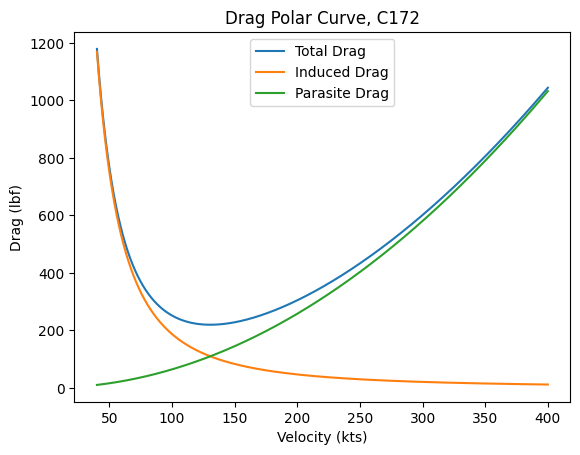

In [5]:
## Drag Polar Plots
V, D, D_i, D_p = drag_polar(alt_0, params,)
plt.plot(V[:], D[:], label = "Total Drag")
plt.plot(V, D_i[:], label = "Induced Drag")
plt.plot(V,D_p[:], label = "Parasite Drag")
plt.legend()
plt.title("Drag Polar Curve, C172")
plt.ylabel("Drag (lbf)")
plt.xlabel("Velocity (kts)")

In [ ]:
## Trim Solver

# initial guess
x0 = np.array([
    300.0,               # thrust guess [lb]
    np.deg2rad(-2.0),    # delta_e guess [rad]
    np.deg2rad(3.0),     # theta guess [rad]
])

sol = root(aircraft_longitudinal_trim_solver, x0, args=(params,), method="hybr")
thrust_trim, delta_e_trim, theta_trim = sol.x

print("success:", sol.success)
print("message:", sol.message)
print("thrust trim [lb]:", thrust_trim)
print("delta_e trim [deg]:", np.rad2deg(delta_e_trim))
print("theta trim [deg]:", np.rad2deg(theta_trim))
print("trim residuals:", aircraft_longitudinal_trim_solver(sol.x, params))

V = params["V_trim"]


alpha_trim = theta_trim 

U_0 = V * np.cos(alpha_trim)
W_0 = V * np.sin(alpha_trim)
Q_0 = 0.0


x_trim = np.array([U_0, W_0, Q_0, theta_trim, alt_0])

params["thrust"] = thrust_trim
params["delta_e"] = delta_e_trim


xdot_trim = aircraft_longitudinal_dynamics(0.0, x_trim, params)

print("u_dot     =", xdot_trim[0])
print("w_dot     =", xdot_trim[1])
print("q_dot     =", xdot_trim[2])
print("theta_dot =", xdot_trim[3])
print("h_dot     =", xdot_trim[4])

success: True
message: The solution converged.
thrust trim [lb]: 217.05256710180734
delta_e trim [deg]: -2.5268517650491225
theta trim [deg]: 2.668464681535553
trim residuals: [ 4.44089210e-16 -2.13162821e-14 -1.18545411e-16]
u_dot     = 4.440892098500626e-16
w_dot     = -2.1316282072803006e-14
q_dot     = -1.1854541099682662e-16
theta_dot = 0.0
h_dot     = 8.881784197001252e-16


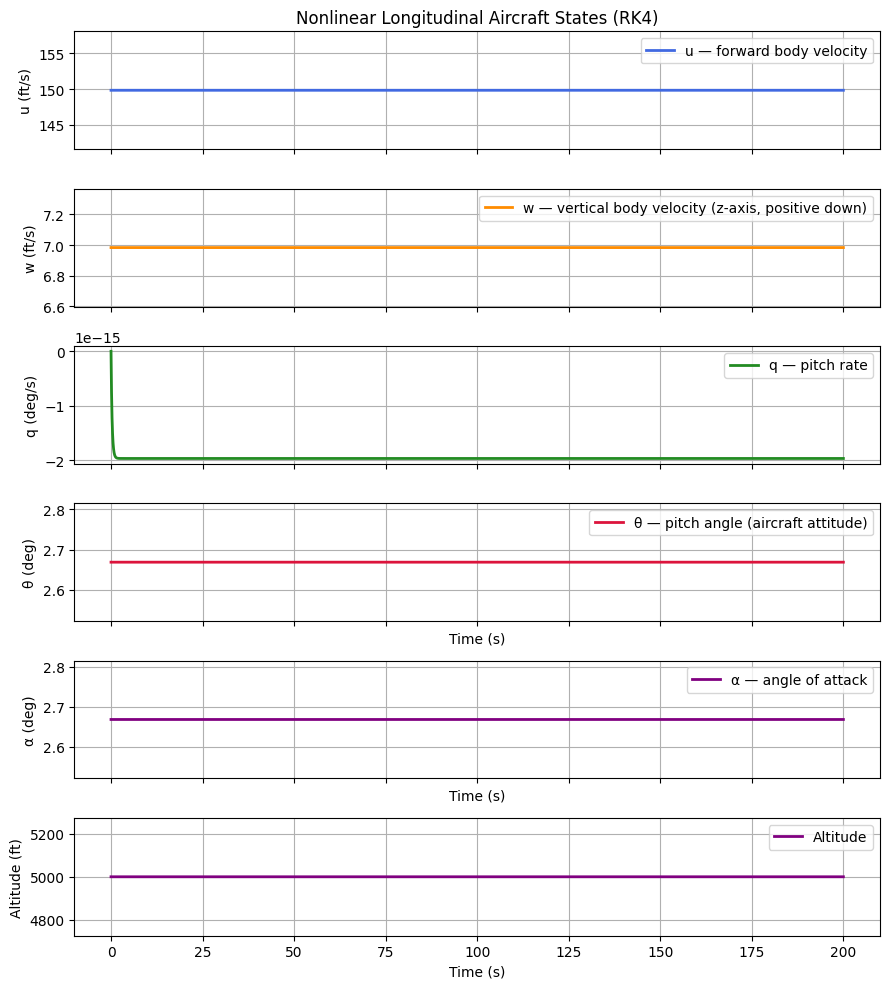

In [7]:
## Dynamics Calculations
    # Uses RK4 script for numerical integration and aircraft_longitudinal_dynamics EOM script

t_rk4, x_rk4 = RK4(aircraft_longitudinal_dynamics, (0.0, tf), [U_0, W_0, Q_0, theta_0, alt_0], dt, args=(params,))
sol = solve_ivp(aircraft_longitudinal_dynamics, (t0,tf), [U_0*np.cos(theta_0),U_0*np.sin(theta_0),0,theta_0,alt_0], args=(params,), method='RK45')


alpha = np.arctan2(x_rk4[:,1], x_rk4[:,0]) # angle of attack calculated from forward and vertical velocity, [rad]

# Dynamics Plots
fig, axs = plt.subplots(6, 1, figsize=(9,10), sharex=True)

axs[0].plot(t_rk4, x_rk4[:,0], color="royalblue", linewidth=2)
axs[0].set_ylabel("u (ft/s)")
axs[0].set_title("Nonlinear Longitudinal Aircraft States (RK4)")
axs[0].legend(["u — forward body velocity"])
axs[0].grid(True)

axs[1].plot(t_rk4, x_rk4[:,1], color="darkorange", linewidth=2)
axs[1].set_ylabel("w (ft/s)")
axs[1].legend(["w — vertical body velocity (z-axis, positive down)"])
axs[1].grid(True)

axs[2].plot(t_rk4, np.rad2deg(x_rk4[:,2]), color="forestgreen", linewidth=2)
axs[2].set_ylabel("q (deg/s)")
axs[2].legend(["q — pitch rate"])
axs[2].grid(True)

axs[3].plot(t_rk4, np.rad2deg(x_rk4[:,3]), color="crimson", linewidth=2)
axs[3].set_ylabel("θ (deg)")
axs[3].set_xlabel("Time (s)")
axs[3].legend(["θ — pitch angle (aircraft attitude)"])
axs[3].grid(True)

axs[4].plot(t_rk4, np.rad2deg(alpha), color="purple", linewidth=2)
axs[4].set_ylabel("α (deg)")
axs[4].set_xlabel("Time (s)")
axs[4].legend(["α — angle of attack"])
axs[4].grid(True)

axs[5].plot(t_rk4,x_rk4[:,4], color="purple", linewidth=2)
axs[5].set_ylabel("Altitude (ft)")
axs[5].set_xlabel("Time (s)")
axs[5].legend(["Altitude"])
axs[5].grid(True)


plt.tight_layout()
plt.show()
